## Crop Yield Prediction: Baseline and Core Models

This notebook uses the merged features in `data/processed/crop_yield_ml_features_with_ndvi.csv` (including NDVI) to train and compare multiple models:

- Linear Regression (baseline)
- Decision Tree
- Random Forest
- XGBoost (if `xgboost` is installed)
- LightGBM (if `lightgbm` is installed)
- Stacking Ensemble

Metrics:
- R² Score
- RMSE
- MAE
- 5-fold cross-validation estimates for all metrics


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not installed; XGBoost model will be skipped.")

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("lightgbm not installed; LightGBM model will be skipped.")

pd.set_option("display.max_columns", None)


In [2]:
# 1. Load merged feature dataset (with NDVI)
data_path = "../data/processed/crop_yield_ml_features_with_ndvi.csv"
df = pd.read_csv(data_path)
print("Shape before dropna:", df.shape)
df = df.dropna(subset=["mean_ndvi"])
print("Shape after dropping rows with missing NDVI:", df.shape)
df.head()

Shape before dropna: (17983, 17)
Shape after dropping rows with missing NDVI: (16970, 17)


,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent,mean_ndvi
0,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,25720.54,68.12,2.780000,78,45,22,6.8,27.74,1070.25,70.73,0.4601
1,Arhar/Tur,2000,Kharif,Andhra Pradesh,507366.0,216457,49808120.22,131915.16,0.433182,78,45,22,6.8,27.74,1070.25,70.73,0.4601
2,Arhar/Tur,2000,Rabi,Andhra Pradesh,6098.0,2701,598640.66,1585.48,0.423750,78,45,22,6.8,27.74,1070.25,70.73,0.4601
3,Bajra,2000,Kharif,Andhra Pradesh,129475.0,135964,12710560.75,33663.50,1.001667,78,45,22,6.8,27.74,1070.25,70.73,0.4601
4,Bajra,2000,Rabi,Andhra Pradesh,14229.0,12524,1396860.93,3699.54,0.883125,78,45,22,6.8,27.74,1070.25,70.73,0.4601


In [3]:
# 2. Define features and target
target_col = "yield"
y = df[target_col].values

# Exclude 'production' to avoid target leakage (yield ≈ production/area)
feature_cols = [
    "crop", "season", "state",  # categorical
    "year", "area", "fertilizer", "pesticide",
    "N", "P", "K", "pH",
    "avg_temp_c", "total_rainfall_mm", "avg_humidity_percent",
    "mean_ndvi",  # NDVI feature
]
X = df[feature_cols].copy()

categorical_cols = ["crop", "season", "state"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

Categorical features: ['crop', 'season', 'state']
Numeric features: ['year', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'mean_ndvi']


In [4]:
# 3. Train/validation split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((13576, 15), (3394, 15))

In [5]:
# 4. Preprocessing: one-hot encode categoricals, scale numerics
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_cols),
        ("numeric", numeric_transformer, numeric_cols),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [6]:
# Helper function to evaluate models
def evaluate_model(name, model):
    print(f"\n=== {name} ===")
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
    }

    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )

    # Fit on full training set and evaluate on hold-out test set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    summary = {
        "model": name,
        "test_r2": r2,
        "test_rmse": rmse,
        "test_mae": mae,
        "cv_r2_mean": cv_results["test_r2"].mean(),
        "cv_r2_std": cv_results["test_r2"].std(),
        "cv_rmse_mean": -cv_results["test_rmse"].mean(),  # invert sign
        "cv_rmse_std": cv_results["test_rmse"].std(),
        "cv_mae_mean": -cv_results["test_mae"].mean(),
        "cv_mae_std": cv_results["test_mae"].std(),
    }

    print("Test R2:", r2)
    print("Test RMSE:", rmse)
    print("Test MAE:", mae)
    print("CV R2 (mean ± std):", summary["cv_r2_mean"], "+/-", summary["cv_r2_std"])
    print("CV RMSE (mean):", summary["cv_rmse_mean"])
    print("CV MAE (mean):", summary["cv_mae_mean"])

    return summary


In [ ]:
# 5. Define models
models = []

# 1. Baseline: Linear Regression
models.append(("Linear Regression", LinearRegression()))

# 2. Core models
models.append(("Decision Tree", DecisionTreeRegressor(random_state=42)))
models.append(("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)))

if XGB_AVAILABLE:
    models.append((
        "XGBoost",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42,
        ),
    ))


# 3. Advanced: LightGBM (if available)
if LGBM_AVAILABLE:
    models.append((
        "LightGBM",
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
        ),
    ))

models

[('Linear Regression', LinearRegression()),
 ('Decision Tree', DecisionTreeRegressor(random_state=42)),
 ('Random Forest',
  RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)),
 ('XGBoost',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=400,
               n_jobs=-1, num_parallel_tree=None, ...)),
 ('SVR (RBF)', SVR(C=10.0

In [8]:
# 6. Run all models and collect results
results = []
for name, mdl in models:
    summary = evaluate_model(name, mdl)
    results.append(summary)

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="test_r2", ascending=False)
results_df_sorted


=== Linear Regression ===
Test R2: 0.8710095944590217
Test RMSE: 326.97083530888557
Test MAE: 57.30680709633584
CV R2 (mean ± std): 0.8510356646480132 +/- 0.011545503119029424
CV RMSE (mean): 340.29866863143786
CV MAE (mean): 60.999816425450184

=== Decision Tree ===
Test R2: 0.9686836777434702
Test RMSE: 161.10747438224848
Test MAE: 11.086451132265173
CV R2 (mean ± std): 0.9625850874561911 +/- 0.015549837872973612
CV RMSE (mean): 166.9899349833883
CV MAE (mean): 11.473585229483163

=== Random Forest ===
Test R2: 0.9804781338220312
Test RMSE: 127.2011326295946
Test MAE: 8.73950317224449
CV R2 (mean ± std): 0.9789118491722151 +/- 0.012672322371794595
CV RMSE (mean): 124.58905730230427
CV MAE (mean): 9.399200844996757

=== XGBoost ===
Test R2: 0.9842786293170527
Test RMSE: 114.14989506192036
Test MAE: 9.878477758327104
CV R2 (mean ± std): 0.9783740144291577 +/- 0.009549245081203079
CV RMSE (mean): 126.95327750344786
CV MAE (mean): 11.476277533031203

=== SVR (RBF) ===
Test R2: 0.0062262

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 13576, number of used features: 99
[LightGBM] [Info] Start training from score 84.167890
Test R2: 0.9788113761406005
Test RMSE: 132.52007970824624
Test MAE: 15.743995463645419
CV R2 (mean ± std): 0.9717203758056465 +/- 0.011173813778426177
CV RMSE (mean): 146.80284316452972
CV MAE (mean): 19.0807820508832


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
3,XGBoost,0.984279,114.149895,9.878478,0.978374,0.009549,126.953278,26.669924,11.476278,2.323057
2,Random Forest,0.980478,127.201133,8.739503,0.978912,0.012672,124.589057,37.234802,9.399201,2.810271
5,LightGBM,0.978811,132.520080,15.743995,0.971720,0.011174,146.802843,32.830027,19.080782,3.027131
1,Decision Tree,0.968684,161.107474,11.086451,0.962585,0.015550,166.989935,35.285488,11.473585,2.693428
0,Linear Regression,0.871010,326.970835,57.306807,0.851036,0.011546,340.298669,17.223113,60.999816,2.970017
4,SVR (RBF),0.006226,907.557357,78.621269,0.003518,0.001974,883.754370,77.578279,80.609798,14.431497


In [9]:
# 7. Stacking Ensemble (advanced)
base_estimators = []
for name, mdl in models:
    if name in ["Linear Regression"]:
        continue
    base_estimators.append((name.replace(" ", "_"), mdl))

final_estimator = LinearRegression()

stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    n_jobs=-1,
)

stack_summary = evaluate_model("Stacking Ensemble", stack_model)
results.append(stack_summary)
results_full = pd.DataFrame(results).sort_values(by="test_r2", ascending=False)
results_full


=== Stacking Ensemble ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2053
[LightGBM] [Info] Number of data points in the train set: 10860, number of used features: 99
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 10861, number of used features: 99
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011723 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Start training from score 86.747633
[LightGBM] [Info] Number of data points in the train set: 10861, number of used f

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 83.711745


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 75.987754


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 8688, number of used features: 99
[LightGBM] [Info] Start training from score 84.699635


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 85.534961


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 80.719118


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002874 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2054
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 82.876107


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 87.238086


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 90.744008


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2053
[LightGBM] [Info] Number of data points in the train set: 8688, number of used features: 99
[LightGBM] [Info] Start training from score 88.620825


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 84.317952


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 75.351034


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 83.700938


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 77.966350


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 72.052810


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 87.180143


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 8688, number of used features: 99
[LightGBM] [Info] Start training from score 83.868240


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 98.956567


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004763 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 93.946362


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 8689, number of used features: 99
[LightGBM] [Info] Start training from score 87.192859


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 8688, number of used features: 99
[LightGBM] [Info] Start training from score 92.814551


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 13576, number of used features: 99
[LightGBM] [Info] Start training from score 84.167890
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 10861, number of used features: 99
[LightGBM] [Info] Start training from score 82.072553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 10861, number of used features: 99
[LightGBM] [Info] Start t

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/

Test R2: 0.981577890280978
Test RMSE: 123.56628645383715
Test MAE: 9.984479509417785
CV R2 (mean ± std): 0.9781255366719247 +/- 0.012381277436501555
CV RMSE (mean): 127.2536457772012
CV MAE (mean): 11.012115569017093


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
3,XGBoost,0.984279,114.149895,9.878478,0.978374,0.009549,126.953278,26.669924,11.476278,2.323057
6,Stacking Ensemble,0.981578,123.566286,9.984480,0.978126,0.012381,127.253646,35.898279,11.012116,3.077941
2,Random Forest,0.980478,127.201133,8.739503,0.978912,0.012672,124.589057,37.234802,9.399201,2.810271
5,LightGBM,0.978811,132.520080,15.743995,0.971720,0.011174,146.802843,32.830027,19.080782,3.027131
1,Decision Tree,0.968684,161.107474,11.086451,0.962585,0.015550,166.989935,35.285488,11.473585,2.693428
0,Linear Regression,0.871010,326.970835,57.306807,0.851036,0.011546,340.298669,17.223113,60.999816,2.970017
4,SVR (RBF),0.006226,907.557357,78.621269,0.003518,0.001974,883.754370,77.578279,80.609798,14.431497


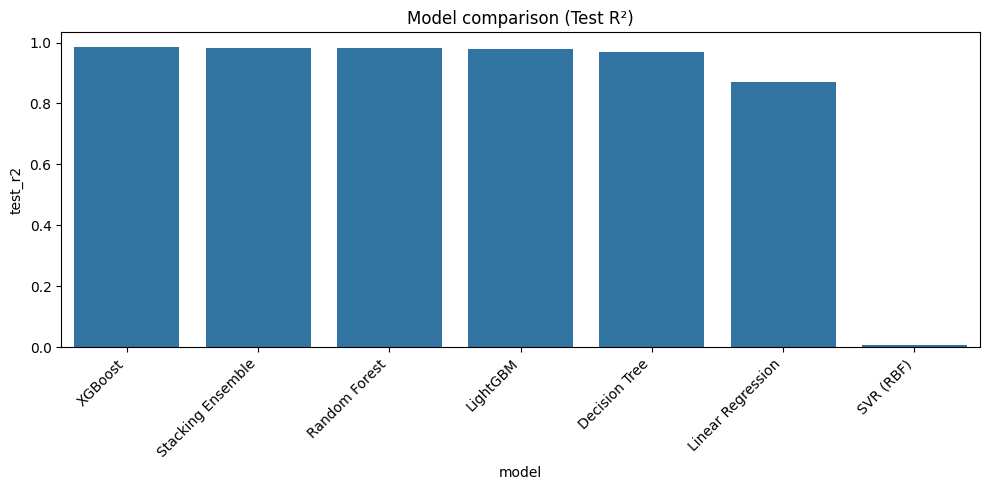

,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
3,XGBoost,0.984279,114.149895,9.878478,0.978374,0.009549,126.953278,26.669924,11.476278,2.323057
6,Stacking Ensemble,0.981578,123.566286,9.984480,0.978126,0.012381,127.253646,35.898279,11.012116,3.077941
2,Random Forest,0.980478,127.201133,8.739503,0.978912,0.012672,124.589057,37.234802,9.399201,2.810271
5,LightGBM,0.978811,132.520080,15.743995,0.971720,0.011174,146.802843,32.830027,19.080782,3.027131
1,Decision Tree,0.968684,161.107474,11.086451,0.962585,0.015550,166.989935,35.285488,11.473585,2.693428
0,Linear Regression,0.871010,326.970835,57.306807,0.851036,0.011546,340.298669,17.223113,60.999816,2.970017
4,SVR (RBF),0.006226,907.557357,78.621269,0.003518,0.001974,883.754370,77.578279,80.609798,14.431497


In [10]:
# 8. Visual comparison of model performance
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_full,
    x="model",
    y="test_r2",
    order=results_full.sort_values("test_r2", ascending=False)["model"],
)
plt.xticks(rotation=45, ha="right")
plt.title("Model comparison (Test R²)")
plt.tight_layout()
plt.show()

results_full